# 08 — Full 10^5-year OEP simulation (GPU pipeline)

End-to-end compound NB-GPD + cooling-hazard uplift + Gumbel copula dependence. Produces the OEP curve cited in §11 of the paper.

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
from dcrisk.monte_carlo.compound import simulate
from dcrisk.monte_carlo.parallel import detect_backend
print('backend:', detect_backend())

backend: jax-gpu


In [2]:
# Start with a 10k-year run; bump to 1e5 once timing is comfortable.
t0 = time.perf_counter()
S = simulate(n_years=10_000, use_gpu=True)
dt = time.perf_counter() - t0
print(f'wall: {dt:.2f}s, mean(S)={S.mean():.2f}, p99.5={S.quantile(0.995):.2f}')

wall: 0.20s, mean(S)=18.05, p99.5=122.56


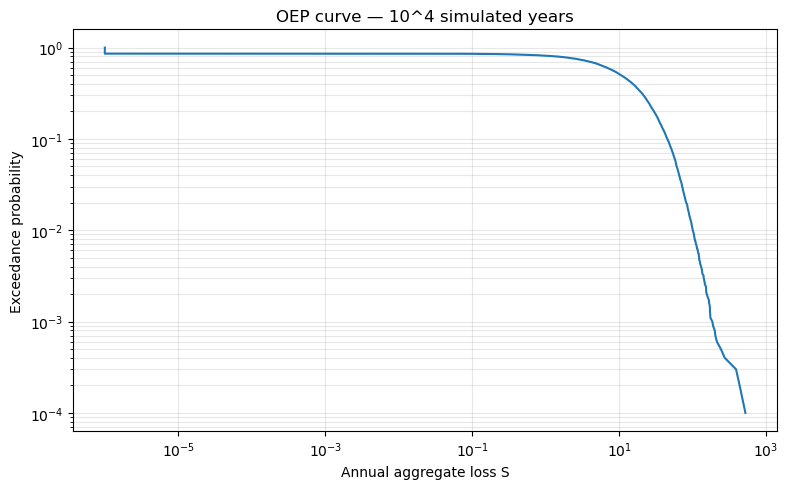

In [3]:
S_sorted = np.sort(S.to_numpy()); n = S_sorted.size; exceed = 1.0 - np.arange(1, n+1)/(n+1)
fig, ax = plt.subplots(figsize=(8, 5))
ax.loglog(np.clip(S_sorted, 1e-6, None), exceed, lw=1.5)
ax.set_xlabel('Annual aggregate loss S'); ax.set_ylabel('Exceedance probability'); ax.set_title('OEP curve — 10^4 simulated years')
ax.grid(which='both', alpha=0.3); fig.tight_layout(); fig.savefig('fig_08_oep.png', dpi=150); plt.show()